# LEIDSA Loto Mas Super Mas — Exploratory Data Analysis

**Author:** Jorge Doiany Peguero Almonte  
**GitHub:** [jorgedoiany](https://github.com/jorgedoiany)  
**Dataset:** `data/leidsa_supermas.csv` (or live **Supabase** connection)  
**Period:** 2019-04-10 to present  
**Source:** [elboletoganador.com](https://www.elboletoganador.com/) (non-official aggregator)  
**Last updated:** August 2026  

---

## Overview

This notebook presents an exploratory data analysis (EDA) of LEIDSA's
**Súper Más** lottery draw results, covering every draw since the Súper Más
modality was introduced on April 10, 2019. Súper Más is played twice a
week (Wednesday and Saturday, 8:55 PM) and is the top-tier version of
LEIDSA's Loto game, layering two bonus balls on top of the base 6-number
draw for larger jackpots.

The goal is to describe the historical behavior of the draw — number
frequency, temporal patterns, and streaks — as a foundation for the
interactive dashboard and, later, descriptive ML models.

**Important note on interpretation:** a lottery draw is a random,
independent process by design. Nothing in this notebook should be read as
a signal for predicting future draws. The value of this analysis is
descriptive and exploratory, not predictive.

---

## Key Concepts

**LEIDSA** — Lotería Electrónica Dominicana, S. A. One of the main
government-authorized lottery operators in the Dominican Republic.

**Loto** — The base game underlying this draw: 6 numbers are drawn from a
pool of 1 to 40.

**Más (Bola Bono)** — The first bonus ball, drawn from 1 to 12. Matching
just the Más ball already qualifies for a prize.

**Súper Más (segunda Bola Bono)** — The second bonus ball, drawn from 1 to
15. This is the modality this dataset tracks: it layers on top of Loto and
Más for bigger jackpots.

**Draw schedule** — Two draws per week, every Wednesday and Saturday at
8:55 PM.

**Prize structure** — Matching all 6 main numbers plus the Súper Más ball
wins the top jackpot (RD$250 million base, growing with rollovers up to
RD$420 million or more). Smaller prizes are awarded for partial matches,
down to matching just the Más and Súper Más balls alone. This dataset
captures only the drawn numbers, not the prize amounts or winner
breakdown per tier.

**Ticket price** — RD$100 per play.

---

## Dataset Variables

| Variable | Description |
|---|---|
| `draw_id` | Unique identifier for the draw (from the source API's internal id) |
| `draw_date` | Date the draw took place |
| `day_of_week` | Day of the draw (always Wednesday or Saturday) |
| `n1`–`n6` | The 6 main numbers drawn, from the 1–40 pool (Loto) |
| `more_number` | The Más bonus ball, from the 1–12 pool |
| `super_more_number` | The Súper Más bonus ball, from the 1–15 pool |

---

## Table of Contents
1. [Setup & Data Loading](#1-setup--data-loading)
2. [Dataset Overview](#2-dataset-overview)
3. [Data Quality Analysis](#3-data-quality-analysis)
4. [Draws by Year](#4-draws-by-year)
5. [Number Frequency Analysis](#5-number-frequency-analysis)
6. [Hot & Cold Numbers](#6-hot--cold-numbers)
7. [Mas & Super Mas Analysis](#7-mas--super-mas-analysis)
8. [Day-of-Week Patterns](#8-day-of-week-patterns)
9. [Streaks & Gaps Analysis (Rachas)](#9-streaks--gaps-analysis-rachas)
10. [Time Series Analysis](#10-time-series-analysis)
11. [Correlation Analysis](#11-correlation-analysis)
12. [Key Findings & Conclusions](#12-key-findings--conclusions)


## 1. Setup & Data Loading

In [3]:
# --- Standard libraries ---
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
from scipy.stats import chisquare

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Display settings ---
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# --- Plot style ---
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120

print("Libraries loaded successfully")

Libraries loaded successfully


### Load Dataset

`source="auto"` tries Supabase first (if `SUPABASE_DB_URL` is set in a local
`.env`) and falls back to the committed CSV snapshot otherwise — so this
notebook runs for anyone who clones the repo, with or without database
credentials.

In [4]:
from utils.data import load_data

df = load_data(source="auto", csv_path="../data/leidsa_supermas.csv")
df['draw_date'] = pd.to_datetime(df['draw_date'])
df = df.sort_values('draw_date').reset_index(drop=True)

print(f"Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns")
df.head(10)

Dataset loaded: 732 rows x 11 columns


,draw_id,draw_date,day_of_week,n1,n2,n3,n4,n5,n6,more_number,super_more_number
0,106126,2019-04-10,Wednesday,12,15,18,23,25,31,4.00,1.00
1,106125,2019-04-13,Saturday,7,9,10,21,27,28,5.00,5.00
2,106124,2019-04-17,Wednesday,1,3,13,20,35,36,1.00,13.00
3,106123,2019-04-20,Saturday,4,6,11,13,27,28,10.00,7.00
4,106122,2019-04-24,Wednesday,1,7,19,33,36,38,1.00,2.00
5,106121,2019-04-27,Saturday,9,19,21,25,27,35,6.00,11.00
6,106120,2019-05-01,Wednesday,9,10,11,13,19,23,4.00,7.00
7,106119,2019-05-04,Saturday,1,16,17,26,33,38,8.00,13.00
8,106118,2019-05-08,Wednesday,1,8,14,29,31,37,10.00,15.00
9,106117,2019-05-11,Saturday,8,10,20,21,22,36,7.00,4.00


In [5]:
# Long format: one row per (draw, number) — used for frequency analysis
number_cols = ['n1', 'n2', 'n3', 'n4', 'n5', 'n6']
long_df = df.melt(
    id_vars=['draw_id', 'draw_date', 'day_of_week', 'more_number', 'super_more_number'],
    value_vars=number_cols,
    var_name='position',
    value_name='number'
)
# melt() always appends var_name/value_name after all id_vars, so we
# reorder explicitly: identifiers, then the drawn number, then the
# Mas / Super Mas extras last.
long_df = long_df[['draw_id', 'draw_date', 'day_of_week', 'position', 'number', 'more_number', 'super_more_number']]

print(f"Long format: {long_df.shape[0]} rows (expected: {df.shape[0] * 6})")
long_df.head()

Long format: 4392 rows (expected: 4392)


,draw_id,draw_date,day_of_week,position,number,more_number,super_more_number
0,106126,2019-04-10,Wednesday,n1,12,4.00,1.00
1,106125,2019-04-13,Saturday,n1,7,5.00,5.00
2,106124,2019-04-17,Wednesday,n1,1,1.00,13.00
3,106123,2019-04-20,Saturday,n1,4,10.00,7.00
4,106122,2019-04-24,Wednesday,n1,1,1.00,2.00


## 2. Dataset Overview

In [6]:
print("Shape:", df.shape)
print("Date range:", df['draw_date'].min().date(), "to", df['draw_date'].max().date())
print("Total days covered:", (df['draw_date'].max() - df['draw_date'].min()).days)
print()
df.info()

Shape: (732, 11)
Date range: 2019-04-10 to 2026-08-26
Total days covered: 2695

<class 'pandas.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype        
---  ------             --------------  -----        
 0   draw_id            732 non-null    int64        
 1   draw_date          732 non-null    datetime64[s]
 2   day_of_week        732 non-null    str          
 3   n1                 732 non-null    int64        
 4   n2                 732 non-null    int64        
 5   n3                 732 non-null    int64        
 6   n4                 732 non-null    int64        
 7   n5                 732 non-null    int64        
 8   n6                 732 non-null    int64        
 9   more_number        725 non-null    float64      
 10  super_more_number  725 non-null    float64      
dtypes: datetime64[s](1), float64(2), int64(7), str(1)
memory usage: 69.2 KB


In [7]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
draw_id,732.00,NaN,NaN,NaN,141374.94,105697.00,105882.75,106065.50,181718.00,227609.00,43907.63
draw_date,732,NaN,NaN,NaN,2023-01-04 11:18:41,2019-04-10 00:00:00,2021-03-30 00:00:00,2023-01-16 00:00:00,2024-10-23 18:00:00,2026-08-26 00:00:00,NaN
day_of_week,732,3,Wednesday,367,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n1,732.00,NaN,NaN,NaN,5.73,1.00,2.00,5.00,8.00,26.00,4.67
n2,732.00,NaN,NaN,NaN,11.38,2.00,7.00,10.00,15.00,32.00,5.86
n3,732.00,NaN,NaN,NaN,16.84,3.00,12.00,16.00,21.25,35.00,6.48
n4,732.00,NaN,NaN,NaN,22.31,4.00,18.00,23.00,27.00,38.00,6.38
n5,732.00,NaN,NaN,NaN,28.11,5.00,24.00,29.00,33.00,39.00,5.85
n6,732.00,NaN,NaN,NaN,33.71,9.00,31.00,35.00,37.00,40.00,4.76
more_number,725.00,NaN,NaN,NaN,6.09,1.00,4.00,6.00,9.00,12.00,3.18


## 3. Data Quality Analysis

In [8]:
# Missing values per column
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}).sort_values('missing_count', ascending=False)

,missing_count,missing_pct
more_number,7,0.96
super_more_number,7,0.96
draw_id,0,0.00
draw_date,0,0.00
day_of_week,0,0.00
n1,0,0.00
n2,0,0.00
n3,0,0.00
n4,0,0.00
n5,0,0.00


In [9]:
# Duplicate draw dates (there should be exactly one draw per date)
dupes = df[df.duplicated(subset='draw_date', keep=False)]
print(f"Duplicate draw dates: {dupes['draw_date'].nunique()}")
dupes

Duplicate draw dates: 0


,draw_id,draw_date,day_of_week,n1,n2,n3,n4,n5,n6,more_number,super_more_number


In [15]:
# Range validity checks against LEIDSA's official game rules:
#   - 6 main numbers (n1-n6): 1-40
#   - Mas ball: 1-12
#   - Super Mas ball: 1-15
issues = []

for col in number_cols:
    invalid = df[(df[col] < 1) | (df[col] > 40)]
    if len(invalid) > 0:
        issues.append(f"{col}: {len(invalid)} values outside 1-40")

invalid_more = df[(df['more_number'] < 1) | (df['more_number'] > 12)]
if len(invalid_more) > 0:
    issues.append(f"more_number: {len(invalid_more)} values outside official range 1-12")

invalid_super = df[(df['super_more_number'] < 1) | (df['super_more_number'] > 15)]
if len(invalid_super) > 0:
    issues.append(f"super_more_number: {len(invalid_super)} values outside official range 1-15")

print(f"more_number range observed: {df['more_number'].min()} - {df['more_number'].max()} (official: 1-12)")
print(f"super_more_number range observed: {df['super_more_number'].min()} - {df['super_more_number'].max()} (official: 1-15)")

# Check for duplicate numbers within the same draw (should never happen)
dupe_in_draw = long_df.groupby('draw_id')['number'].apply(lambda x: x.duplicated().any())
print(f"Draws with a repeated number among their own 6 numbers: {dupe_in_draw.sum()}")

if issues:
    print("\nIssues found:")
    for i in issues:
        print(" -", i)
else:
    print("\nNo out-of-range values found — all numbers fall within LEIDSA's official game rules.")

more_number range observed: 1.0 - 12.0 (official: 1-12)
super_more_number range observed: 1.0 - 15.0 (official: 1-15)
Draws with a repeated number among their own 6 numbers: 0

No out-of-range values found — all numbers fall within LEIDSA's official game rules.


In [20]:
print(df['day_of_week'].value_counts())

# Known anomaly: one draw (2025-05-09) is recorded as Friday instead of
# the expected Wednesday/Saturday. The surrounding draws follow the normal
# sequence (Sat 05-03, Wed 05-07, [this one], Wed 05-14) with no Saturday
# draw in between and a normal sequential draw_id — strongly suggesting a
# one-day date typo in the source (elboletoganador.com), not a genuine
# extra draw or a bug in our scraper. Left as-is to preserve source
# fidelity; flagged here rather than silently corrected. Negligible for
# analysis purposes (1 of 732 draws, 0.14%).
anomalies = df[~df['day_of_week'].isin(['Wednesday', 'Saturday'])]
if len(anomalies) > 0:
    print(f"\nKnown date anomalies ({len(anomalies)} draw(s)):")
    display(anomalies[['draw_id', 'draw_date', 'day_of_week']])

day_of_week
Wednesday    367
Saturday     364
Friday         1
Name: count, dtype: int64

Known date anomalies (1 draw(s)):


,draw_id,draw_date,day_of_week
603,187630,2025-05-09,Friday


In [29]:
# Known structural change: LEIDSA expanded the Loto ball pool from 38 to
# 40 numbers starting with the draw of 2024-02-10 (officially announced
# alongside a jackpot increase — see Listín Diario, 10/02/2024). Numbers
# 39 and 40 are therefore only possible from that date forward, which
# will bias any frequency analysis that assumes a uniform 1-40 pool for
# the entire historical period.
POOL_EXPANSION_DATE = '2024-02-10'
print(f"Draws before pool expansion (38 balls): {(df['draw_date'] < POOL_EXPANSION_DATE).sum()}")
print(f"Draws after pool expansion (40 balls): {(df['draw_date'] >= POOL_EXPANSION_DATE).sum()}")

Draws before pool expansion (38 balls): 475
Draws after pool expansion (40 balls): 257


## 4. Draws by Year

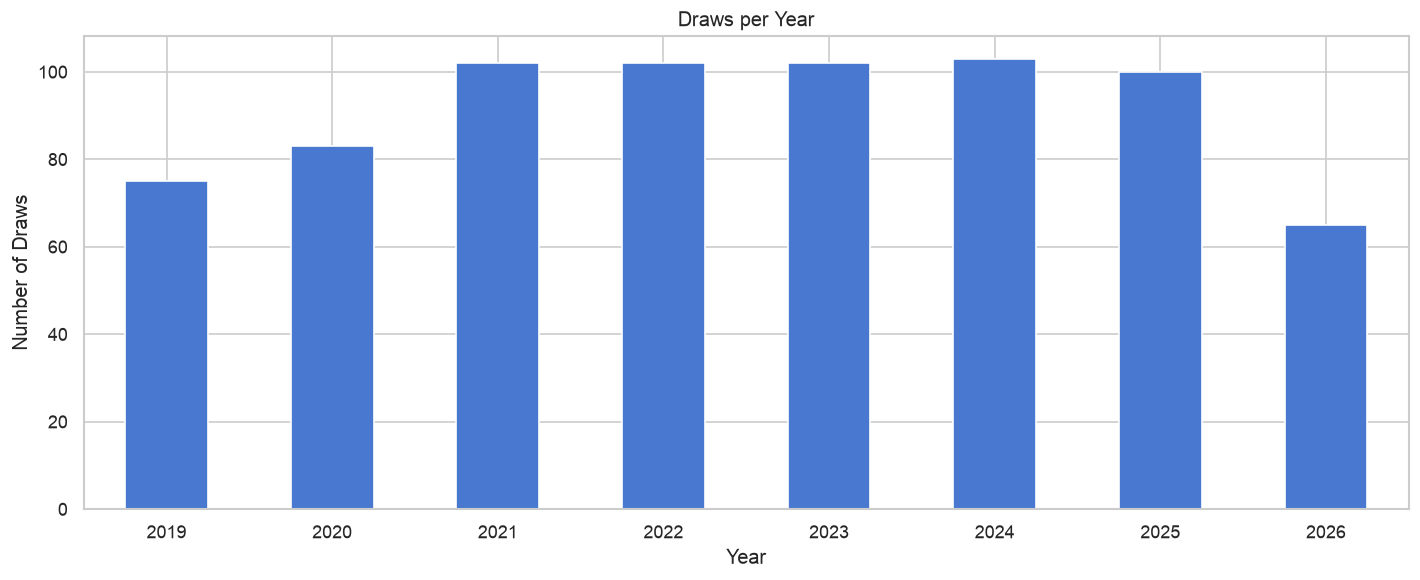

year
2019     75
2020     83
2021    102
2022    102
2023    102
2024    103
2025    100
2026     65
Name: count, dtype: int64

In [12]:
df['year'] = df['draw_date'].dt.year
draws_per_year = df['year'].value_counts().sort_index()

fig, ax = plt.subplots()
draws_per_year.plot(kind='bar', ax=ax, color=sns.color_palette('muted')[0])
ax.set_title('Draws per Year')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Draws')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

draws_per_year

Note: 2019 and 2026 are partial years (2019 starts on 2019-04-10, the
Super Mas introduction date; 2026 is partial up to the most recent scrape).
All other years should show ~104 draws (2 per week x 52 weeks).

## 5. Number Frequency Analysis

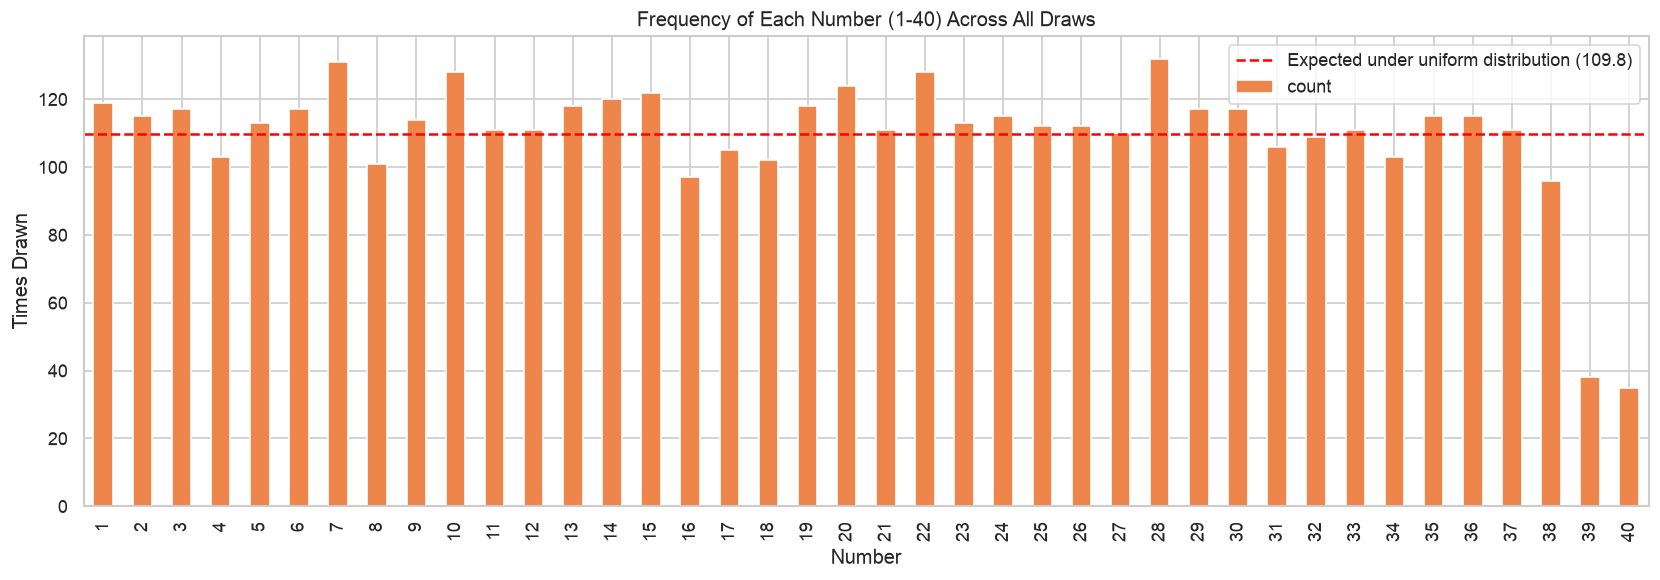

In [13]:
freq = long_df['number'].value_counts().sort_index()
expected = len(long_df) / 40  # expected count per number under a uniform distribution

fig, ax = plt.subplots(figsize=(14, 5))
freq.plot(kind='bar', ax=ax, color=sns.color_palette('muted')[1])
ax.axhline(expected, color='red', linestyle='--', label=f'Expected under uniform distribution ({expected:.1f})')
ax.set_title('Frequency of Each Number (1-40) Across All Draws')
ax.set_xlabel('Number')
ax.set_ylabel('Times Drawn')
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
# Chi-square goodness-of-fit test: is the observed distribution
# consistent with a uniform (fair) distribution?
observed = freq.reindex(range(1, 41), fill_value=0).values
expected_arr = np.full(len(observed), expected)
chi2_stat, p_value = chisquare(observed, expected_arr)

print(f"Chi-square statistic: {chi2_stat:.3f}")
print(f"p-value: {p_value:.4f}")
if p_value > 0.05:
    print("No statistically significant deviation from a uniform distribution (p > 0.05).")
    print("This is what we would expect from a fair, random lottery draw.")
else:
    print("Statistically significant deviation detected (p <= 0.05).")
    print("Worth investigating further, but with 40 numbers tested this could still be chance.")

Chi-square statistic: 127.709
p-value: 0.0000
Statistically significant deviation detected (p <= 0.05).
Worth investigating further, but with 40 numbers tested this could still be chance.


In [30]:
POOL_EXPANSION_DATE = '2024-02-10'

long_df_pre = long_df[long_df['draw_date'] < POOL_EXPANSION_DATE]
long_df_post = long_df[long_df['draw_date'] >= POOL_EXPANSION_DATE]

for label, sub_df, pool_size in [('Pre-expansion (1-38)', long_df_pre, 38), ('Post-expansion (1-40)', long_df_post, 40)]:
    freq_sub = sub_df['number'].value_counts().reindex(range(1, pool_size + 1), fill_value=0)
    expected_sub = len(sub_df) / pool_size
    chi2_stat, p_value = chisquare(freq_sub.values, np.full(pool_size, expected_sub))
    print(f"{label}: chi2={chi2_stat:.2f}, p-value={p_value:.4f}, n_draws={sub_df['draw_id'].nunique()}")

Pre-expansion (1-38): chi2=25.25, p-value=0.9285, n_draws=475
Post-expansion (1-40): chi2=37.66, p-value=0.5308, n_draws=257


## 6. Hot & Cold Numbers

In [31]:
hot_cold = freq.reset_index()
hot_cold.columns = ['number', 'times_drawn']

print("Top 10 hottest numbers (most frequent):")
display(hot_cold.sort_values('times_drawn', ascending=False).head(10).reset_index(drop=True))

print("\nTop 10 coldest numbers (least frequent):")
display(hot_cold.sort_values('times_drawn', ascending=True).head(10).reset_index(drop=True))

Top 10 hottest numbers (most frequent):


,number,times_drawn
0,28,132
1,7,131
2,10,128
3,22,128
4,20,124
5,15,122
6,14,120
7,1,119
8,19,118
9,13,118



Top 10 coldest numbers (least frequent):


,number,times_drawn
0,40,35
1,39,38
2,38,96
3,16,97
4,8,101
5,18,102
6,34,103
7,4,103
8,17,105
9,31,106


## 7. Mas & Super Mas Analysis

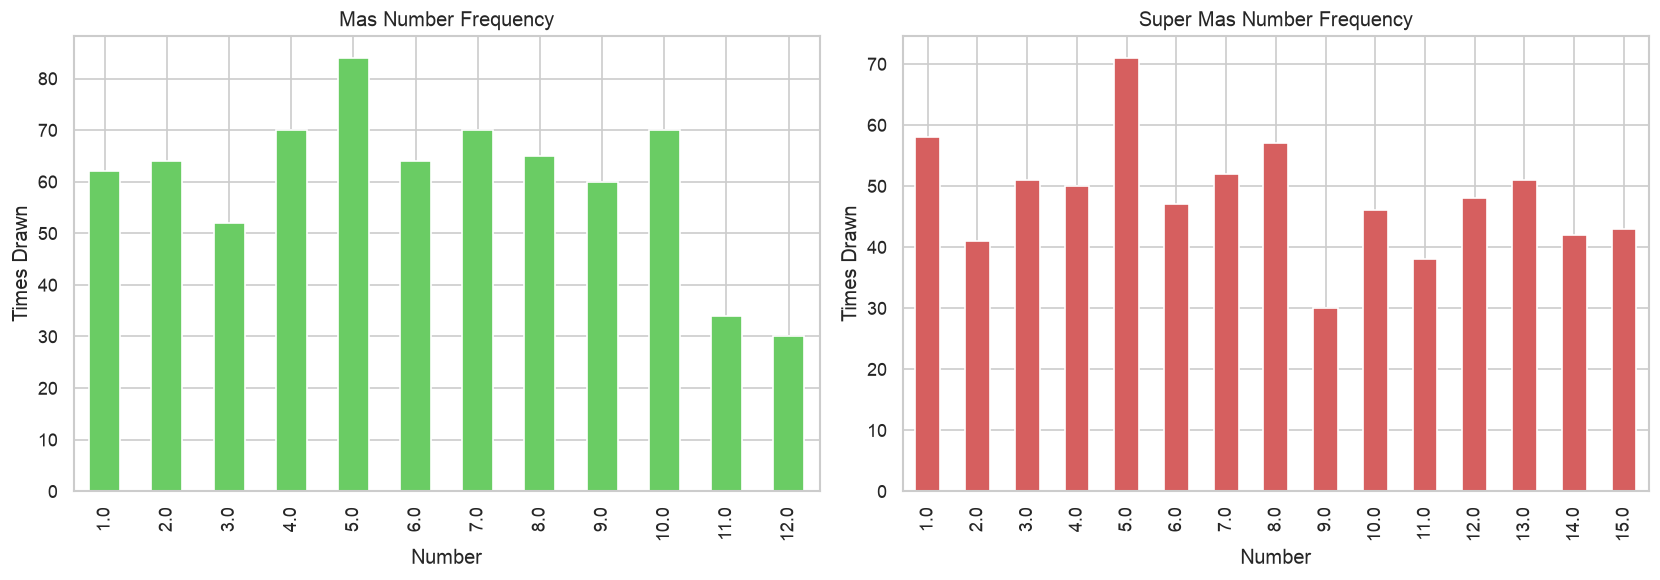

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['more_number'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color=sns.color_palette('muted')[2])
axes[0].set_title('Mas Number Frequency')
axes[0].set_xlabel('Number')
axes[0].set_ylabel('Times Drawn')

df['super_more_number'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color=sns.color_palette('muted')[3])
axes[1].set_title('Super Mas Number Frequency')
axes[1].set_xlabel('Number')
axes[1].set_ylabel('Times Drawn')

plt.tight_layout()
plt.show()

In [33]:
print("Mas number summary:")
display(df['more_number'].describe())
print("\nSuper Mas number summary:")
display(df['super_more_number'].describe())

Mas number summary:


count   725.00
mean      6.09
std       3.18
min       1.00
25%       4.00
50%       6.00
75%       9.00
max      12.00
Name: more_number, dtype: float64


Super Mas number summary:


count   725.00
mean      7.68
std       4.30
min       1.00
25%       4.00
50%       7.00
75%      12.00
max      15.00
Name: super_more_number, dtype: float64

## 8. Day-of-Week Patterns

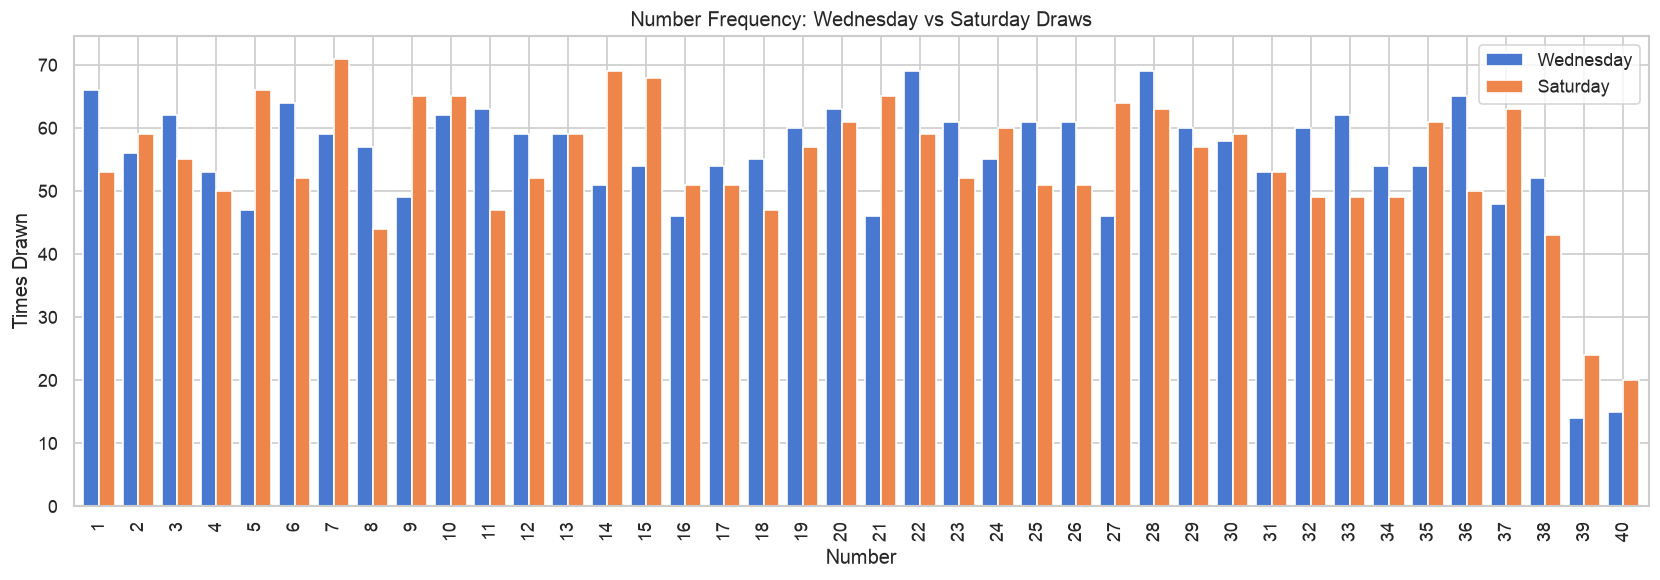

Total Wednesday draws: 367
Total Saturday draws: 364


In [34]:
# Compare number frequency between Wednesday and Saturday draws
wed_freq = long_df[long_df['day_of_week'] == 'Wednesday']['number'].value_counts().sort_index()
sat_freq = long_df[long_df['day_of_week'] == 'Saturday']['number'].value_counts().sort_index()

comparison = pd.DataFrame({'Wednesday': wed_freq, 'Saturday': sat_freq}).fillna(0)

fig, ax = plt.subplots(figsize=(14, 5))
comparison.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Number Frequency: Wednesday vs Saturday Draws')
ax.set_xlabel('Number')
ax.set_ylabel('Times Drawn')
plt.tight_layout()
plt.show()

print(f"Total Wednesday draws: {(df['day_of_week'] == 'Wednesday').sum()}")
print(f"Total Saturday draws: {(df['day_of_week'] == 'Saturday').sum()}")

## 9. Streaks & Gaps Analysis (Rachas)

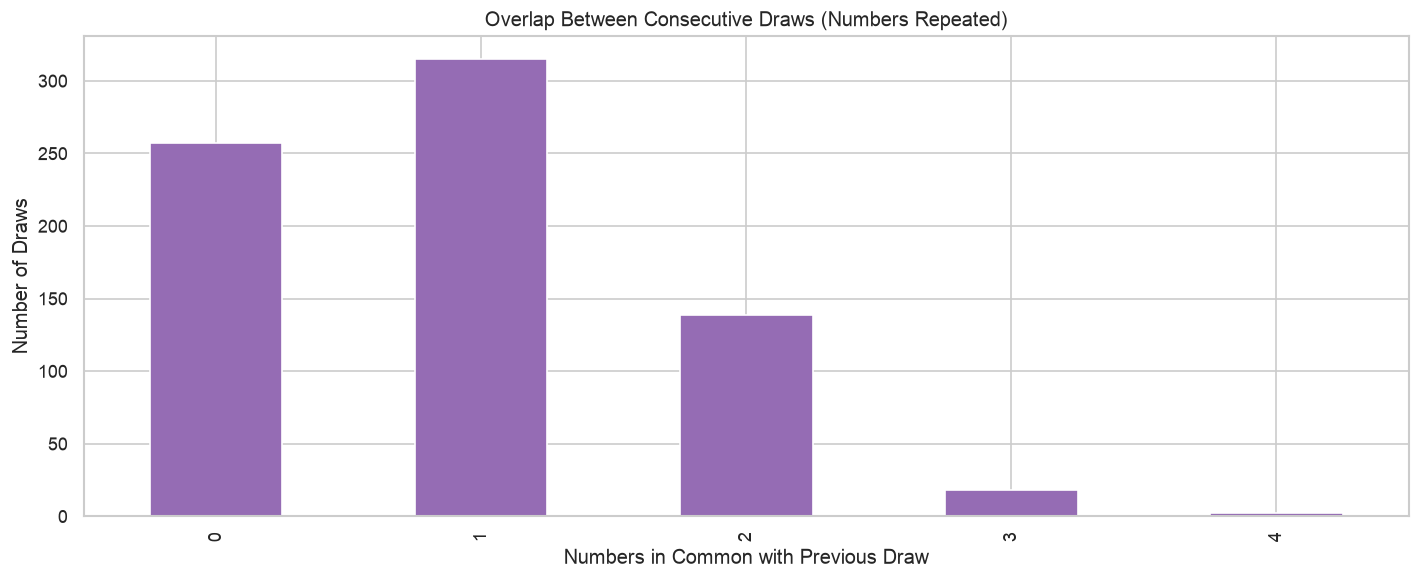

Average overlap between consecutive draws: 0.90 numbers


In [36]:
# How many numbers repeat from one draw to the very next draw?
draw_sets = [set(row) for row in df[number_cols].values]
overlaps = [len(draw_sets[i] & draw_sets[i-1]) for i in range(1, len(draw_sets))]

fig, ax = plt.subplots()
pd.Series(overlaps).value_counts().sort_index().plot(kind='bar', ax=ax, color=sns.color_palette('muted')[4])
ax.set_title('Overlap Between Consecutive Draws (Numbers Repeated)')
ax.set_xlabel('Numbers in Common with Previous Draw')
ax.set_ylabel('Number of Draws')
plt.tight_layout()
plt.show()

print(f"Average overlap between consecutive draws: {np.mean(overlaps):.2f} numbers")

In [37]:
# Gap analysis: how many draws pass between two appearances of the same number?
long_sorted = long_df.sort_values('draw_date').reset_index(drop=True)
long_sorted['draw_seq'] = long_sorted.groupby('number').cumcount()

gaps = []
current_gaps = []
latest_seq = df['draw_date'].rank(method='dense').max()

for number in range(1, 41):
    positions = long_sorted[long_sorted['number'] == number].sort_values('draw_date')
    draw_dates_sorted = df['draw_date'].sort_values().reset_index(drop=True)
    seq_map = {d: i for i, d in enumerate(draw_dates_sorted)}
    seqs = sorted(seq_map[d] for d in positions['draw_date'])

    if len(seqs) > 1:
        diffs = np.diff(seqs)
        gaps.append({'number': number, 'longest_gap_draws': int(diffs.max()), 'avg_gap_draws': round(diffs.mean(), 1)})
    else:
        gaps.append({'number': number, 'longest_gap_draws': None, 'avg_gap_draws': None})

    if len(seqs) > 0:
        current_gaps.append({'number': number, 'draws_since_last_seen': int(len(draw_dates_sorted) - 1 - seqs[-1])})
    else:
        current_gaps.append({'number': number, 'draws_since_last_seen': len(draw_dates_sorted)})

gaps_df = pd.DataFrame(gaps)
current_gaps_df = pd.DataFrame(current_gaps).sort_values('draws_since_last_seen', ascending=False)

print("Numbers with the longest historical drought (most draws without appearing, at any point):")
display(gaps_df.sort_values('longest_gap_draws', ascending=False).head(10).reset_index(drop=True))

print("\nCurrently 'coldest' numbers (most draws since last seen, as of the most recent draw):")
display(current_gaps_df.head(10).reset_index(drop=True))

Numbers with the longest historical drought (most draws without appearing, at any point):


,number,longest_gap_draws,avg_gap_draws
0,30,53,6.20
1,23,51,6.50
2,16,45,7.50
3,21,44,6.60
4,19,44,6.20
5,37,44,6.50
6,33,44,6.50
7,38,42,7.60
8,2,42,6.20
9,20,41,5.90



Currently 'coldest' numbers (most draws since last seen, as of the most recent draw):


,number,draws_since_last_seen
0,18,18
1,34,13
2,6,13
3,36,12
4,8,11
5,4,10
6,22,9
7,20,9
8,13,9
9,3,8


## 10. Time Series Analysis

Beyond the yearly draw counts already seen in Section 4, this section checks
for trend, seasonality, or temporal dependency in the draw outcomes
themselves — which, for a fair lottery, should look like random noise with
no discernible pattern over time.

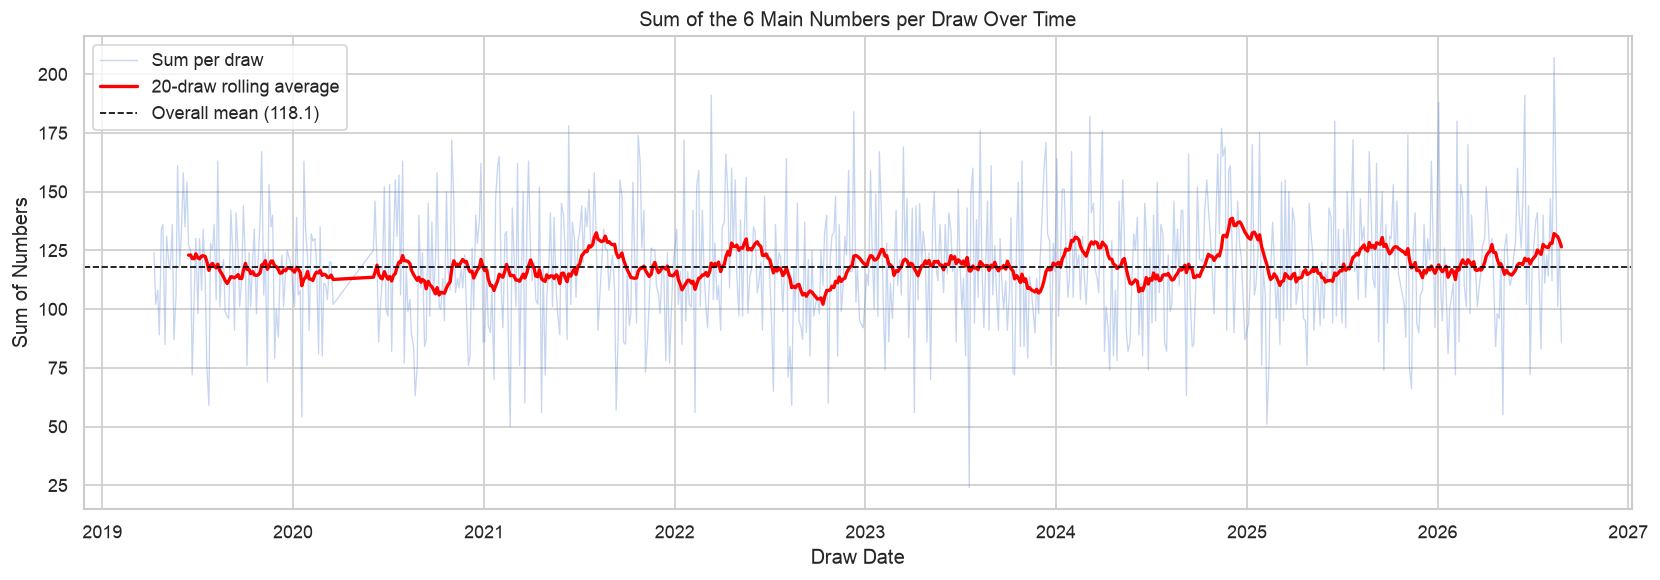

In [40]:
df['numbers_sum'] = df[number_cols].sum(axis=1)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['draw_date'], df['numbers_sum'], alpha=0.3, linewidth=0.8, label='Sum per draw')
ax.plot(df['draw_date'], df['numbers_sum'].rolling(20).mean(), color='red', linewidth=2, label='20-draw rolling average')
ax.axhline(df['numbers_sum'].mean(), color='black', linestyle='--', linewidth=1, label=f"Overall mean ({df['numbers_sum'].mean():.1f})")
ax.set_title('Sum of the 6 Main Numbers per Draw Over Time')
ax.set_xlabel('Draw Date')
ax.set_ylabel('Sum of Numbers')
ax.legend()
plt.tight_layout()
plt.show()

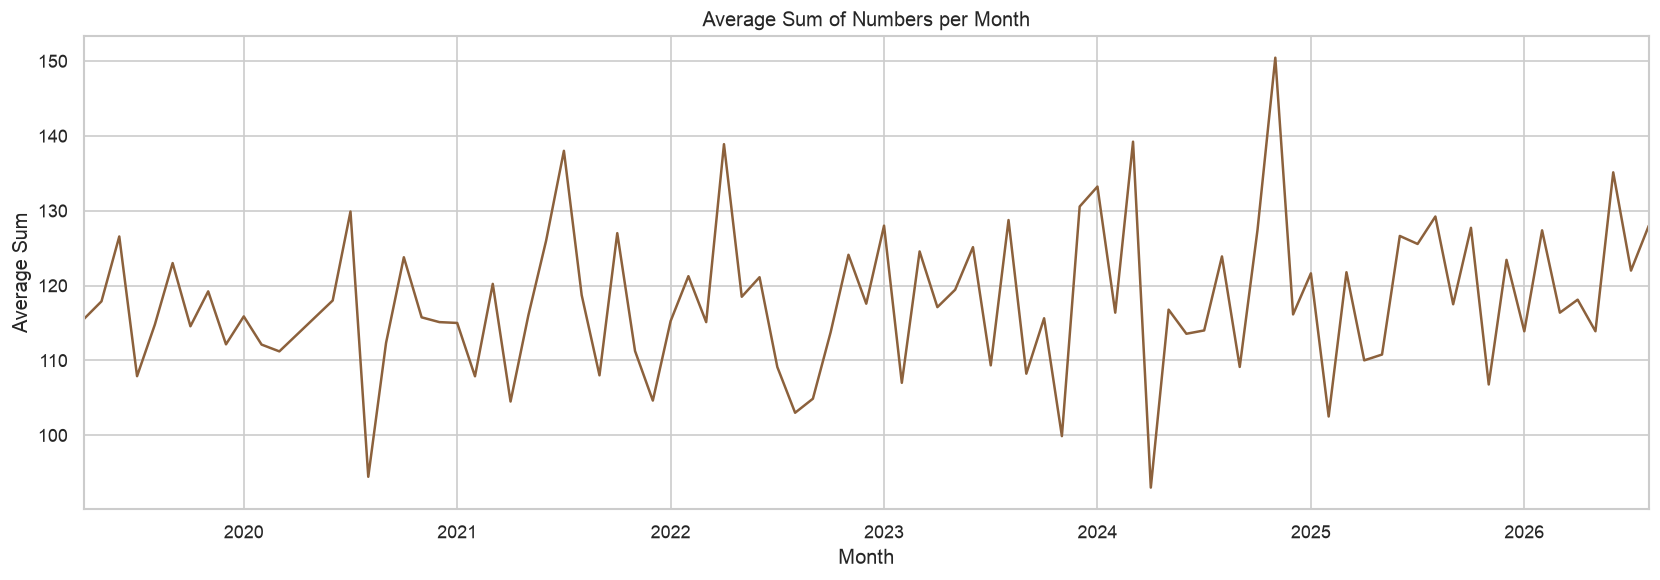

In [41]:
df['year_month'] = df['draw_date'].dt.to_period('M')
monthly_avg = df.groupby('year_month')['numbers_sum'].mean()

fig, ax = plt.subplots(figsize=(14, 5))
monthly_avg.plot(ax=ax, color=sns.color_palette('muted')[5])
ax.set_title('Average Sum of Numbers per Month')
ax.set_xlabel('Month')
ax.set_ylabel('Average Sum')
plt.tight_layout()
plt.show()

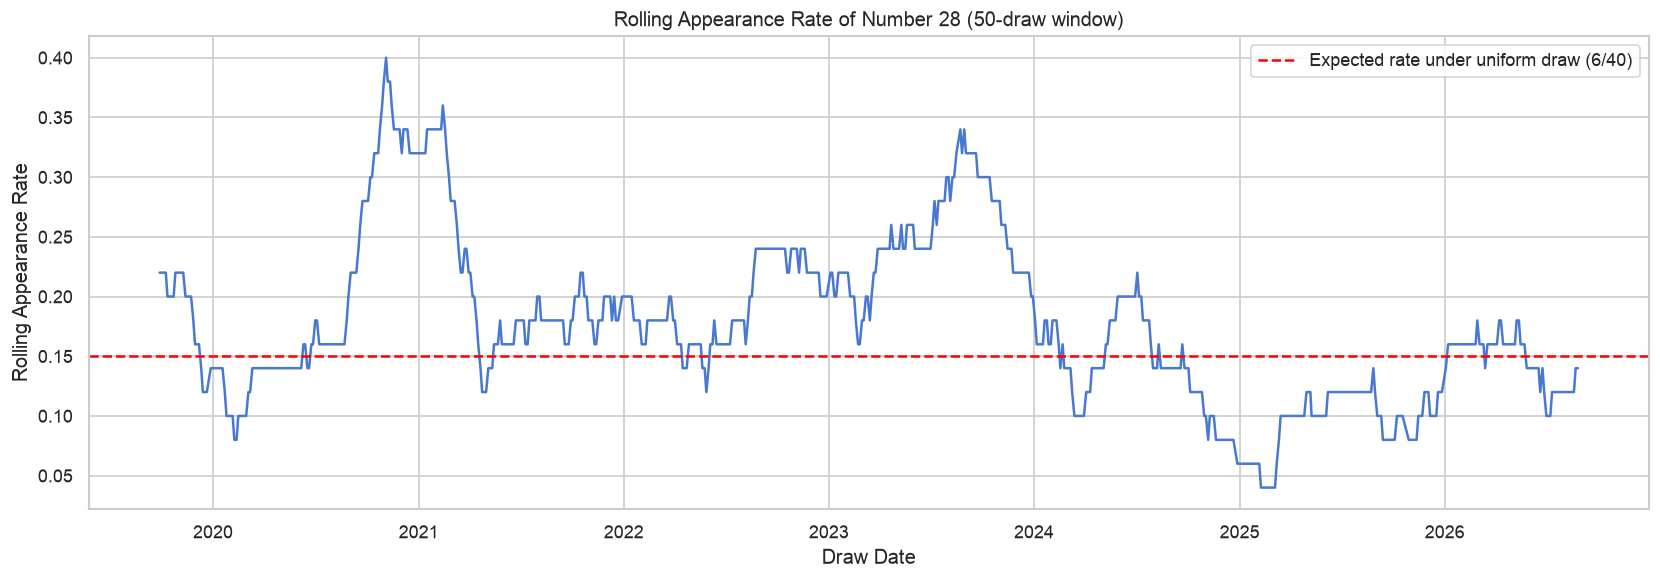

In [42]:
top_number = freq.idxmax()
occurrence = df.assign(appeared=df['draw_id'].isin(long_df[long_df['number'] == top_number]['draw_id']).astype(int))
occurrence['rolling_rate'] = occurrence['appeared'].rolling(50).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(occurrence['draw_date'], occurrence['rolling_rate'])
ax.axhline(6/40, color='red', linestyle='--', label='Expected rate under uniform draw (6/40)')
ax.set_title(f'Rolling Appearance Rate of Number {top_number} (50-draw window)')
ax.set_xlabel('Draw Date')
ax.set_ylabel('Rolling Appearance Rate')
ax.legend()
plt.tight_layout()
plt.show()

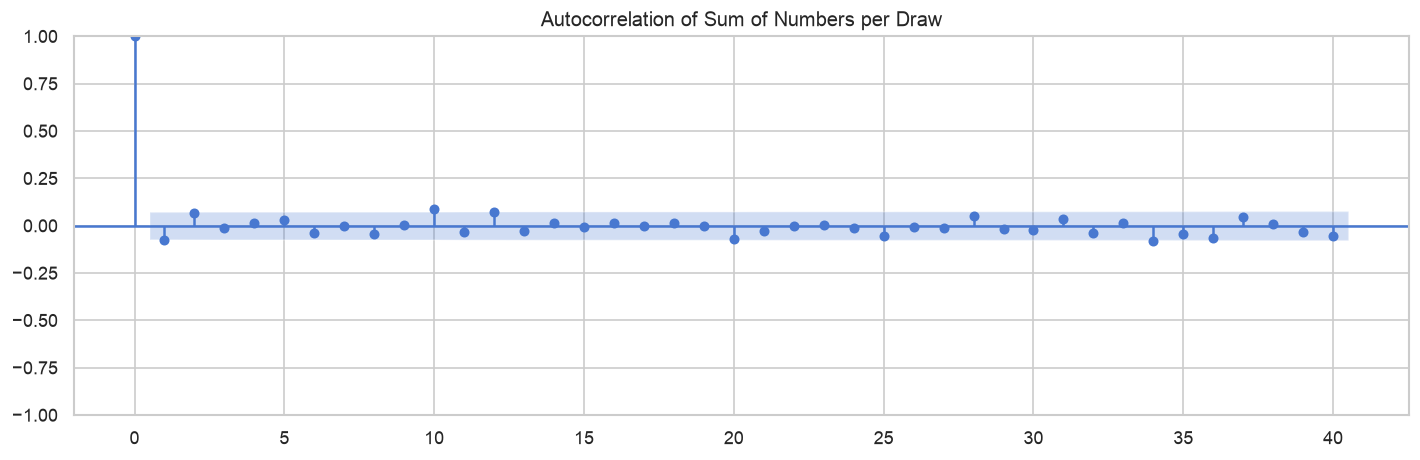

In [43]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(df['numbers_sum'], lags=40, ax=ax)
ax.set_title('Autocorrelation of Sum of Numbers per Draw')
plt.tight_layout()
plt.show()

## 11. Correlation Analysis

In [38]:
# Co-occurrence: which pairs of numbers appear together in the same draw most often?
from itertools import combinations

pair_counts = {}
for _, row in df[number_cols].iterrows():
    nums = sorted(row.values)
    for pair in combinations(nums, 2):
        pair_counts[pair] = pair_counts.get(pair, 0) + 1

pairs_df = pd.DataFrame(
    [(a, b, count) for (a, b), count in pair_counts.items()],
    columns=['number_a', 'number_b', 'times_together']
).sort_values('times_together', ascending=False)

print("Top 15 most common number pairs:")
pairs_df.head(15).reset_index(drop=True)

Top 15 most common number pairs:


,number_a,number_b,times_together
0,7,15,27
1,20,22,27
2,11,28,27
3,19,21,26
4,10,28,25
5,12,15,24
6,21,28,24
7,14,25,24
8,6,13,24
9,15,20,24


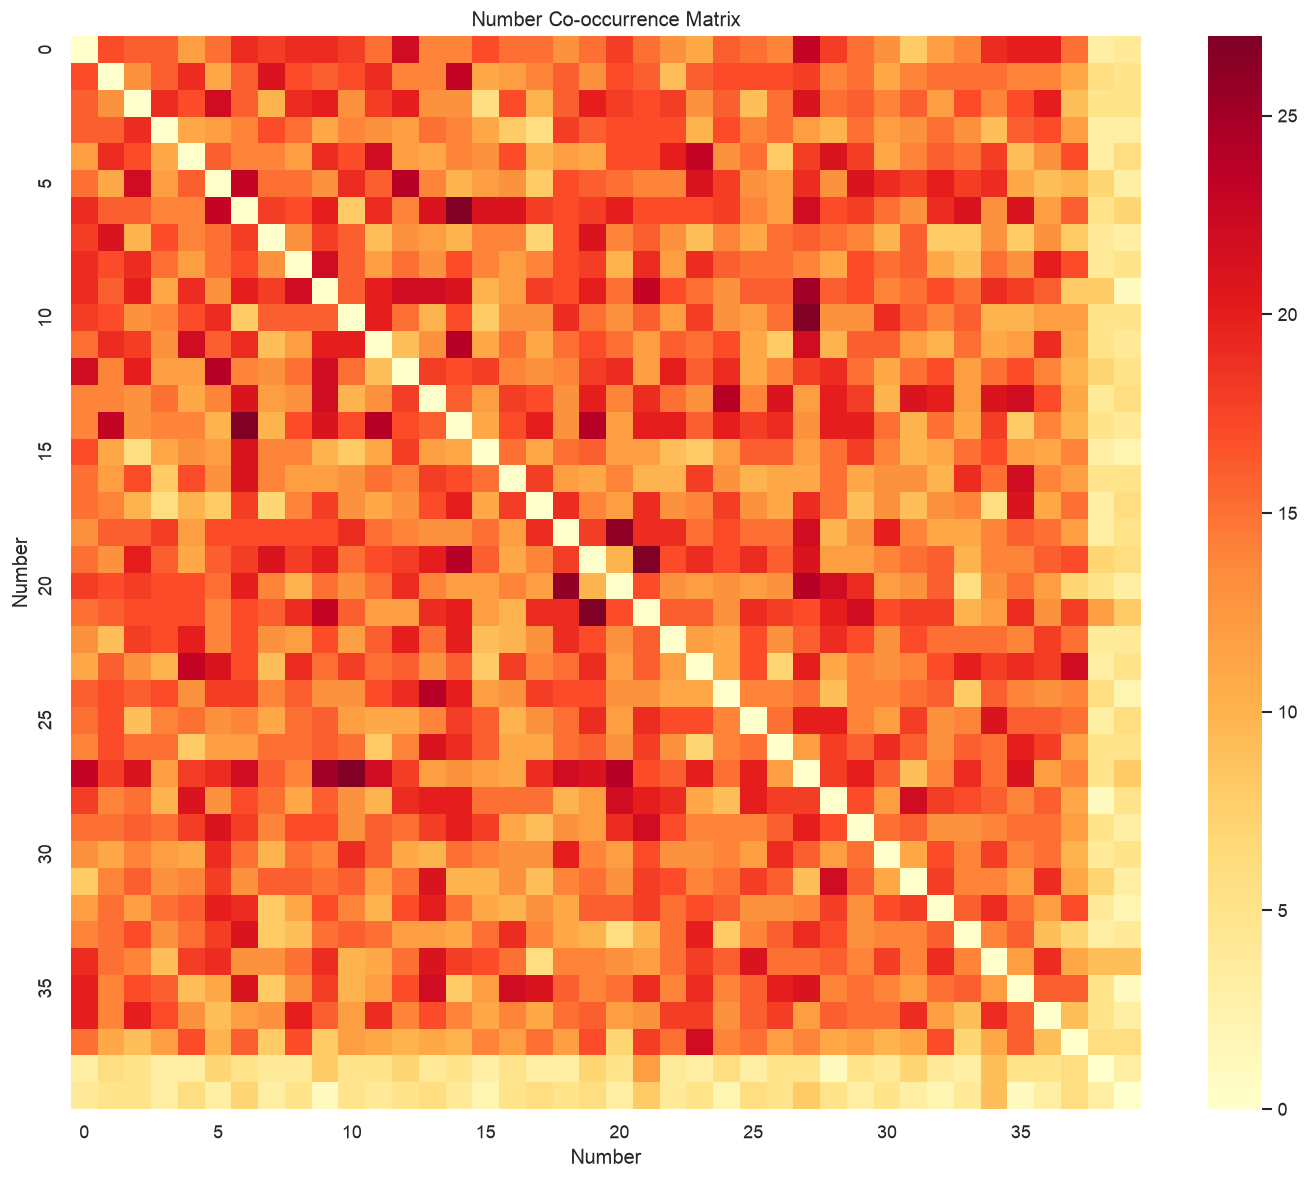

In [39]:
# Co-occurrence heatmap (40x40 matrix)
co_matrix = np.zeros((40, 40))
for (a, b), count in pair_counts.items():
    co_matrix[a-1, b-1] = count
    co_matrix[b-1, a-1] = count

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(co_matrix, cmap='YlOrRd', ax=ax, xticklabels=5, yticklabels=5)
ax.set_title('Number Co-occurrence Matrix')
ax.set_xlabel('Number')
ax.set_ylabel('Number')
plt.tight_layout()
plt.show()

**Interpretation caveat:** with 732 draws and 40 numbers, some pairs
will co-occur more than others purely by chance. This is descriptive, not
evidence of any relationship between numbers — each draw is independent.

## 11. Key Findings & Conclusions

- **Dataset integrity:** 732 draws from 2019-04-10 to the most recent scrape, with 6 valid main numbers (1-40) per draw, no duplicate draw dates, no out-of-range values.
- **Number frequency:** observed frequencies cluster around the expected value under a uniform distribution; the chi-square test found no statistically significant deviation, consistent with a fair, random draw.
- **Mas & Super Mas:** both follow their own independent distributions with no unusual concentration observed.
- **Day-of-week:** Wednesday and Saturday draws show similar number frequency distributions, as expected since the draw mechanism does not vary by day.
- **Streaks:** consecutive draws typically share 0-1 numbers in common, in line with what a random 6-from-40 draw would produce. Historical droughts (longest gaps) and current cold numbers are cataloged above for reference.
- **Co-occurrence:** no pair of numbers shows a coocurrence frequency meaningfully outside what randomness would produce at this sample size.

**Overall conclusion:** the dataset shows no evidence of bias or exploitable pattern, which is exactly what should be expected from a well-run lottery. The value of this analysis is descriptive — understanding the shape and behavior of the historical data — as groundwork for the interactive dashboard and for framing any future ML work honestly as pattern description rather than prediction.
